[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/mhuertascompany/euclid-school-2026/blob/main/Y1/notebooks/1a-linear_regression.ipynb)

If you run the notebook locally, you need to chose your kernel. If your environment does not appear, open a terminal, activate the environment and runfile
`Sometimes your notebook runnner (vscode or jupyter) does not automaticaly recognise the new environment. You need to run

`python -m ipykernel install --user --name DL_intro --display-name "Python (DL intro)"`

You should then be able to select the kernel!

# #1a Linear regression with neural network on one gene

Our first implementation of a neural network is going to be the worst idea of when to use deep learning: trying to fit a linear problem!

But it is worth it, as it is the perfect example to show the common deep learning algorithm steps presented during the course, with the simplest architecture and loss you can imagine.

To still make it slightly interesting, we're going to apply it to the lHubble Law

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import torch

### Fix the seeds for reproducibility

In [2]:
seed = 10

np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False

## Step 1: Define your data
Our data comes from TCGA breast cancer (BRCA) patients. Our input (X) is the gene expression (RNA-seq), and our ground truth / labels (Y) are the CNV computed with ASCAT.

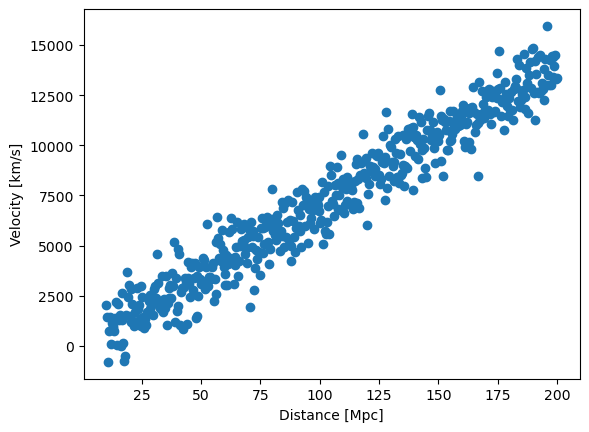

In [3]:

# True Hubble constant
H0 = 70  # km/s/Mpc

# Simulated galaxy distances
d = np.linspace(10, 200, 500)

# Recession velocities + observational/peculiar-velocity noise
v = H0 * d + np.random.normal(0, 1000, size=len(d))

plt.scatter(d, v)
plt.xlabel("Distance [Mpc]")
plt.ylabel("Velocity [km/s]")
plt.show()

## Step 2: Pre-process your data

We see that our data needs normalisation.
we standardise our data by taking out the mean of the data, and dividing by the standard deviation

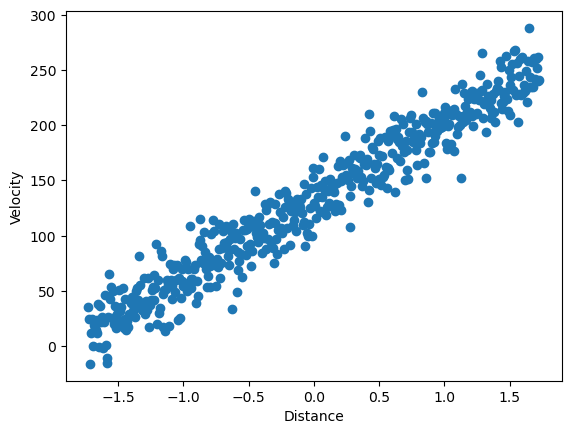

In [4]:
mean_d = np.mean(d)
std_d = np.std(d)
norm_d = (d - mean_d) / std_d

mean_v = np.mean(d)
std_v = np.std(d)
norm_v = (v - mean_v) / std_v

plt.scatter(norm_d, norm_v)
plt.xlabel("Distance")
plt.ylabel("Velocity")
plt.show()

## Creating the datasets
Now that we have pre-processed our data, we need to create our training, validation and testing sets.

We then transform them to torch tensors.

In [5]:
# set the number of samples per group
n_train_samples = int(0.8*len(norm_d))
n_validation_samples = int(0.1*len(norm_d))
n_test_samples = int(0.1*len(norm_d))

# randomise your data for random reprentation in each group
random_samples_ids = np.arange(len(norm_d))
np.random.shuffle(random_samples_ids)

# get the random ids
train_ids = random_samples_ids[:n_train_samples]
validation_ids = random_samples_ids[n_train_samples:n_train_samples+n_validation_samples]
test_ids = random_samples_ids[-n_test_samples:]

# create the sets
x_train = norm_d[train_ids]
y_train = norm_v[train_ids]

x_validation = norm_d[validation_ids]
y_validation = norm_v[validation_ids]

x_test = norm_d[test_ids]
y_test = norm_v[test_ids]


We plot the three sets.

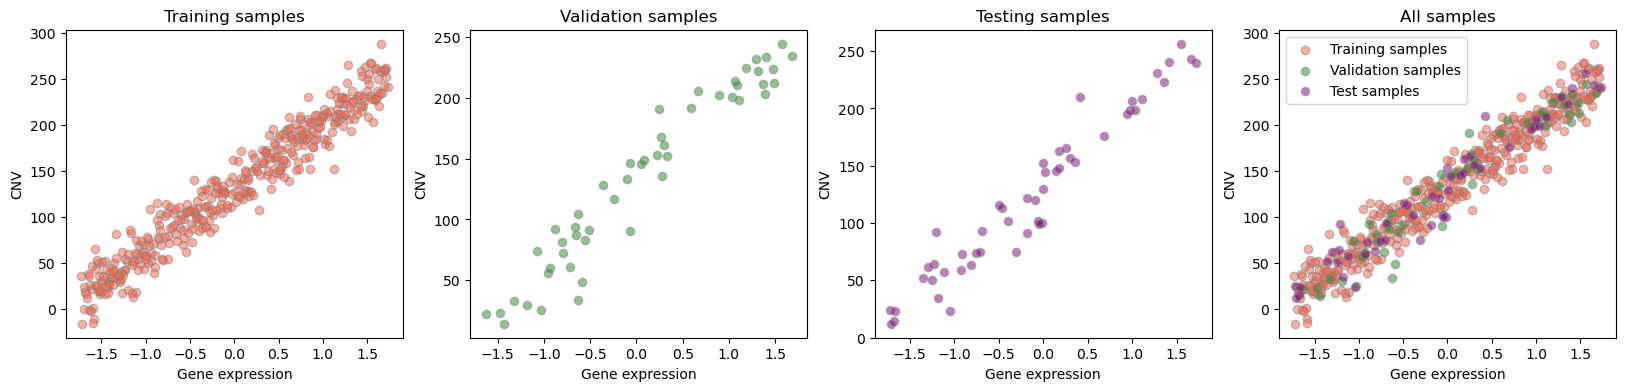

In [6]:
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
plt.subplots_adjust(wspace=0.2)

ax[0].scatter(x_train, y_train, c='tomato', alpha=0.5, edgecolors='gray', label='Training samples')
ax[1].scatter(x_validation, y_validation, c='forestgreen', alpha=0.5, edgecolors='gray', label='Validation samples')
ax[2].scatter(x_test, y_test, c='purple', alpha=0.5, edgecolors='gray', label='Test samples')

ax[3].scatter(x_train, y_train, c='tomato', alpha=0.5, edgecolors='gray', label='Training samples')
ax[3].scatter(x_validation, y_validation, c='forestgreen', alpha=0.5, edgecolors='gray', label='Validation samples')
ax[3].scatter(x_test, y_test, c='purple', alpha=0.5, edgecolors='gray', label='Test samples')
ax[3].legend()

ax[0].set_title('Training samples')
ax[1].set_title('Validation samples')
ax[2].set_title('Testing samples')
ax[3].set_title('All samples')
[axe.set_xlabel('Gene expression') for axe in ax]
[axe.set_ylabel('CNV') for axe in ax];

We transform the numpy array to torch tensors

In [7]:
x_train = torch.unsqueeze(torch.from_numpy(x_train).float(), dim=1)
y_train = torch.unsqueeze(torch.from_numpy(y_train).float(), dim=1)

x_validation = torch.unsqueeze(torch.from_numpy(x_validation).float(), dim=1)
y_validation = torch.unsqueeze(torch.from_numpy(y_validation).float(), dim=1)

x_test = torch.unsqueeze(torch.from_numpy(x_test).float(), dim=1)
y_test = torch.unsqueeze(torch.from_numpy(y_test).float(), dim=1)

In [8]:
print(f'train shape: {x_train.shape}')
print(f'validation shape: {x_validation.shape}')
print(f'test shape: {x_test.shape}')

train shape: torch.Size([400, 1])
validation shape: torch.Size([50, 1])
test shape: torch.Size([50, 1])


In [9]:
print(f'train shape: {y_train.shape}')
print(f'validation shape: {y_validation.shape}')
print(f'test shape: {y_test.shape}')

train shape: torch.Size([400, 1])
validation shape: torch.Size([50, 1])
test shape: torch.Size([50, 1])


## Step 3: Defining the model
Our model here is the simplest model possible: it's one neuron, that is going to do:

$y = w_0*x + b_0$, where y is our velocity prediction, $w_0$ is the unique weight of our model and $b_0$ the unique bias, 

To do so, we use torch, with a Linear layer, with one input (the distance) and one output (the velocity)

In [10]:
class LinearRegressionModel(torch.nn.Module):

    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(1, 1)  # One in and one out

    def forward(self, x):
        y_pred = self.linear(x)
        return y_pred

In [11]:
our_model = LinearRegressionModel()
total_params = sum(p.numel() for p in our_model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 2


## Step 4: Define Loss and optimizer
We also need to define our loss function and the gradient descent algorithm. We are going to use the mean square error loss, and the stochastic gradient descent with a learning rate of 1e-3:

In [12]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(our_model.parameters(), lr = 0.03)

## Step 5-9: Training
We are now ready to train. we define a number of epochs (50), and loop through these epochs, training on all training data at once.

For each epoch:

- Step 5: we feed the gene expression data to our model which output a prediction.

- Step 6: With this prediction and the corresponding ground truth, we compute the loss.

- Step 7: with the loss, we compute the gradient And we apply the gradeints to update the weights of our model.

- Step 8: We do step 5 and 6 on the validation data.

- Step 9: loop.



In [13]:
n_epochs = 70

In [14]:

train_losses = []
val_losses = []

for epoch in range(n_epochs):
    # Step 5: use the model to predict on the epoch
    our_model.train()  # when there is a difference in training / eval / test, for example dropout, 
    pred_y = our_model(x_train)

    # Step 6: Compute the taining loss on the epoch and log it
    loss = criterion(pred_y, y_train)

    # Zero gradients (not accumulate)
    optimizer.zero_grad()
    
    # Step 7 compute the gradients and apply the gradients to optimise
    loss.backward()
    optimizer.step()

    # Keep track of the losses during training    
    train_losses.append(loss.detach().numpy())


    # Step 8: same in validation (without 7)
    our_model.eval()
    pred_y_validation = our_model(x_validation)
    val_loss = criterion(pred_y_validation, y_validation)
    val_losses.append(val_loss.detach().numpy())


## Plot the training loss
Now that our model is trained, we can compute the loss, first diagnostic to see if our model is learning.

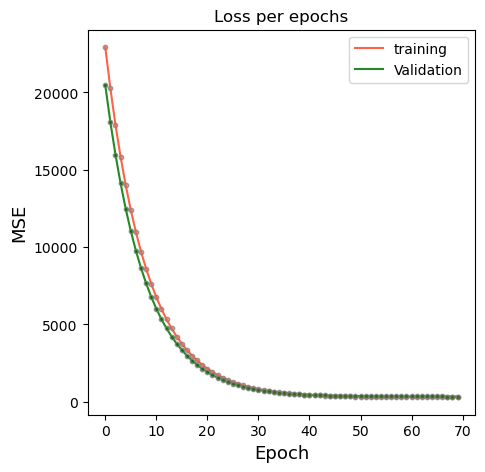

In [15]:
fig, ax = plt.subplots(1, figsize=(5, 5))
plt.subplots_adjust(wspace=0.3)

# Training
ax.scatter(np.arange(len(train_losses)), train_losses, alpha=0.7, s=10, c='tomato', zorder=5, edgecolors='gray')
ax.plot(np.arange(len(train_losses)), train_losses, c='tomato', label='training')

# Validation
ax.scatter(np.arange(len(val_losses)), val_losses, alpha=0.7, s=10, c='darkgreen', zorder=5, edgecolors='gray')
ax.plot(np.arange(len(val_losses)), val_losses, c='forestgreen', label='Validation')

ax.set_ylabel('MSE', fontsize=13)
ax.set_xlabel('Epoch', fontsize=13)
ax.set_title('Loss per epochs')
plt.legend();

We see that at each epoch, our loss is decreasing: our model is learning!

## Step 10: Prediction on the testing set
We can now see what our model is predicting given gene expression. We show the results on the training set (left) and on the testing set (right).

In [16]:
our_model.eval()
pred_on_train = our_model(x_train)
pred_on_test = our_model(x_test)

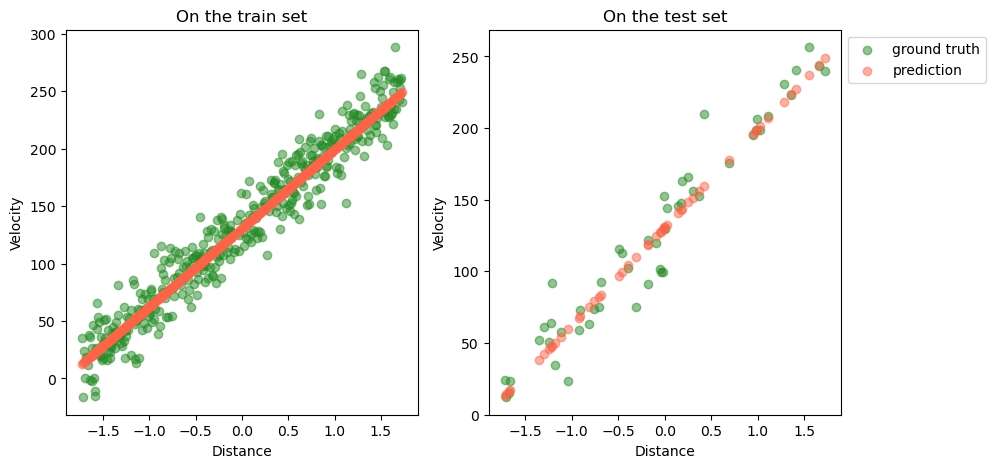

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(x_train, y_train, color='forestgreen', alpha=0.5, label='ground truth')
ax[0].scatter(x_train, pred_on_train.detach().numpy(), color='tomato', alpha=0.5, label='prediction')

ax[1].scatter(x_test, y_test, color='forestgreen', alpha=0.5, label='ground truth')
ax[1].scatter(x_test, pred_on_test.detach().numpy(), color='tomato', alpha=0.5, label='prediction')

ax[1].legend(bbox_to_anchor=(1, 1), loc='upper left')

[axe.set_xlabel('Distance') for axe in ax]
[axe.set_ylabel('Velocity') for axe in ax]

ax[0].set_title('On the train set')
ax[1].set_title('On the test set');


We see that our model as learnt a linear regression trying to fit our more or less linear data. Our model can't do more: it has only one neuron, without activation. It's a pure linear fit!

We can actually print the weights of the model:

In [18]:
w_0 = our_model.linear.weight
b_0 = our_model.linear.bias

In [19]:
print(f'w_0: {w_0.data[0][0]}')
print(f'b_0: {b_0.data[0]}')

w_0: 68.3912124633789
b_0: 130.88201904296875


In [27]:
H0 = w_0 * std_v / std_d
print(f'H0: {H0.detach().numpy()[0]}')


H0: [68.39121]


## Metrics
The last step of the classic deep learning algorithm is to quantify the learning on metrics (usually different than the loss (becasue metrics are not always differentiable...))
Here the classic metric would be the MSE, so we don't have more to do!